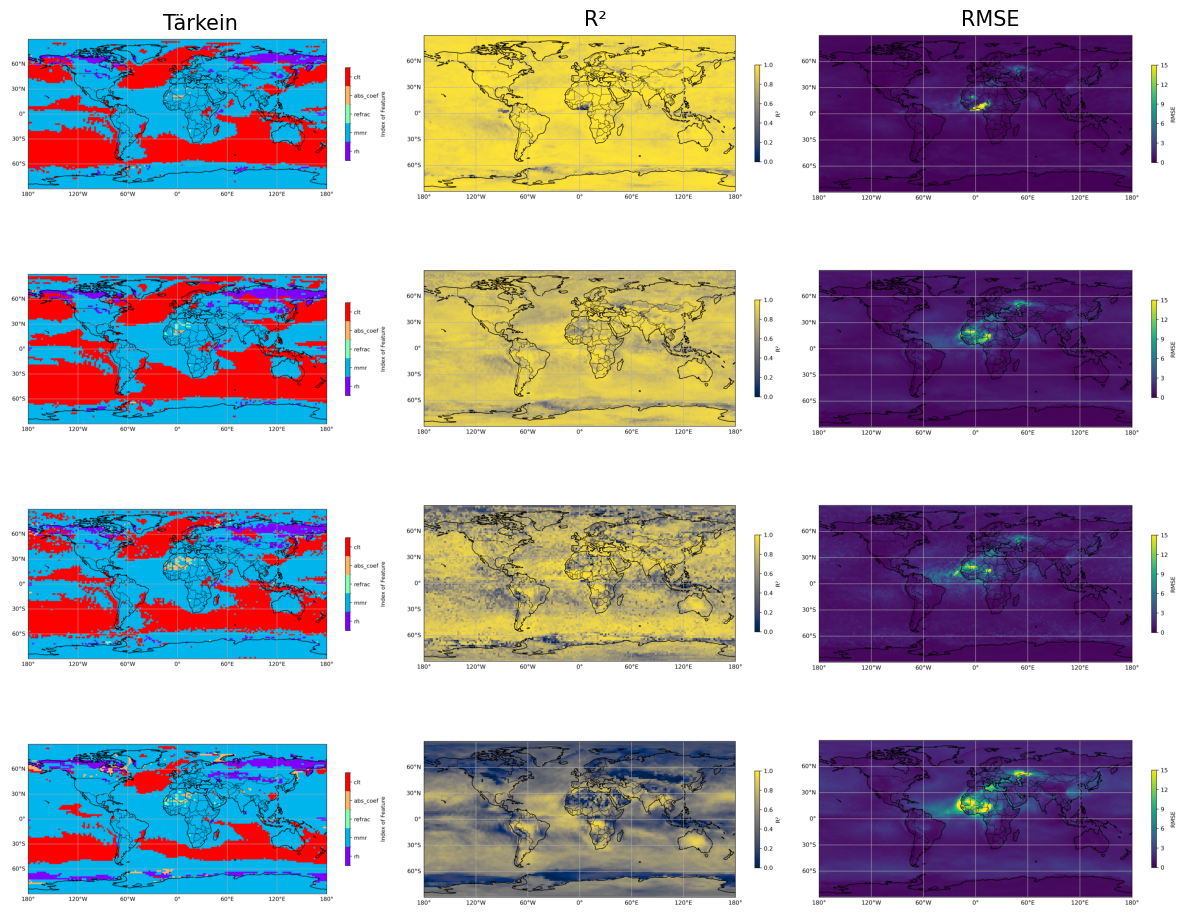

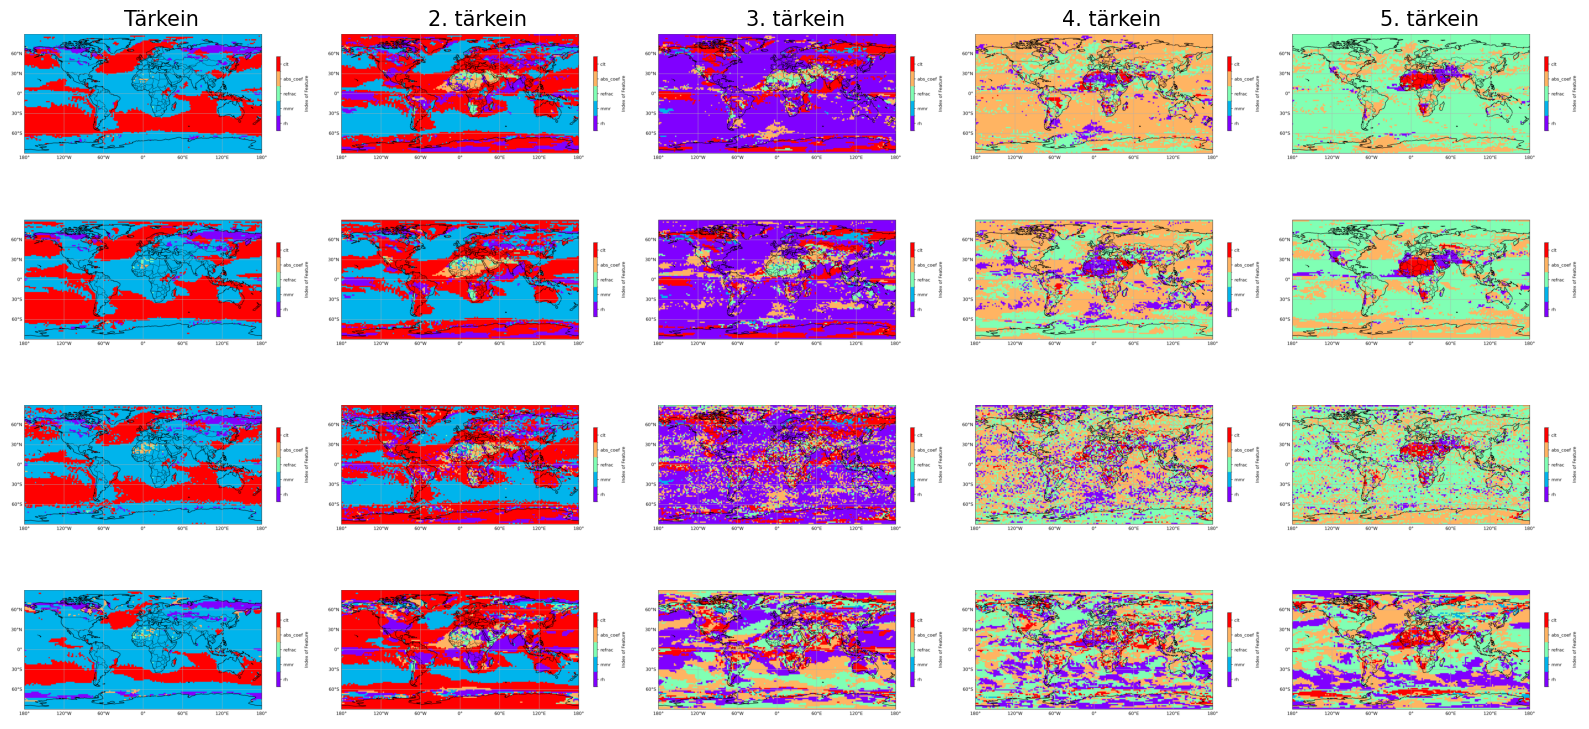

In [13]:
import numpy as np
import sys, os
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.table import Table
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm
import matplotlib as mpl

"""
by Atte Laakso / Aalto University

For gathering plots of domain-trained models into a table
"""
###################################################################################

# define parameters for this image
path = "../FI_results"
models = ['GB','RF','DT','LR']
domain = '1'
dataset = 'dARE_ML_data_250721'

###################################################################################

md = {}
# get data for all models
for model in models:
    folder = os.path.join(path, f'data={dataset}_multimodel=True_model={model}/')
    data = {}
    for i in range(5):
        data[i+1] = os.path.join(folder, f'FI_5feats_static_{domain}_by_{domain}_grids_w_{model}_rank{i+1}.png')
    data['R2'] = os.path.join(folder, f'R2s_for__FI_5feats_static_{domain}_by_{domain}_grids_w_{model}_map.png')
    data['RMSE'] = os.path.join(folder, f'RMSE_for__FI_5feats_static_{domain}_by_{domain}_grids_w_{model}_map.png')
    md[model] = data

# define headers and data-keys
headers1 = ["Tärkein","R²","RMSE"]
keys1    = [1,'R2','RMSE']
out1 = "results_table_w_errors.png"
w1 = 12
h1 = 10

headers2 = ["Tärkein","2. tärkein","3. tärkein","4. tärkein","5. tärkein"]
keys2    = [1,2,3,4,5]
out2 = "results_table_FIs.png"
w2=16
h2=8


def foto(headers,keys,out,w,h):
    # init plot
    fig, axes = plt.subplots(len(models), len(keys), figsize=(w, h))
    n=len(models)
    
    # get images
    for i, model in enumerate(models):
        for j, key in enumerate(keys):
            ax = axes[i, j]
            img_path = md[model][key]
            ax.axis('off')
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                # crop only Fi indices out
                if 'rank' in img_path.lower():
                    # crop rows and columns: [y1:y2, x1:x2, :]
                    cropped = img[20:2000, 20:3000, :]
                    ax.imshow(cropped)
                else:
                    # crop rows and columns: [y1:y2, x1:x2, :]
                    cropped = img[20:2000, 20:3000, :]
                    ax.imshow(cropped)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        
    # add column headers
    for j, header in enumerate(headers):
        axes[0, j].set_title(header, fontsize=15)

    for i, model in enumerate(models):
        # add row labels
        axes[i,0].set_ylabel(model,fontsize=15)
    
    plt.subplots_adjust(left=0.1)
    plt.tight_layout()
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    return

# make figures
foto(headers1,keys1,out1,w1,h1)
foto(headers2,keys2,out2,w2,h2)